# HLLRD V2 Trace Reconstruction Inspection

Visual inspection notebook for the South-East trombone event. It overlays:

- raw ADS-B track
- event raw-window segment
- model centerline
- normal-only HLLRD reconstruction
- stored tangent-lifted HLLRD reconstruction

The default model path is the trace-augmented V2 artifact created during the HRRLD/HLLRD v2 work:

`/tmp/hllrd_se_v2_extend_only_trace_augmented_extra_model.npz`

If that file is missing, run the regeneration commands in the setup cell.

In [1]:
from __future__ import annotations

import argparse
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "pyproject.toml").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from hllrd.cli import _load_raw_tracks_for_event_evaluation
from hllrd.fit import _event_row_extension, _event_row_lag
from hllrd.evaluate import (
    _point_to_polyline_distances,
    _raw_polyline_window,
    _raw_track_polylines,
    _rms,
    _tangents_from_normals,
    center_path_xy,
    closest_raw_track_points_to_matrix_stations,
    evaluate_event_trace_match,
    event_reconstruction_matrix,
)
from hllrd.fit import load_fit_result
from hllrd.geometry import LocalProjection
from hllrd.matrix import load_matrix_artifact

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True})

In [2]:
MATRIX_PATH = PROJECT_ROOT / "data/hllrd/south-east/matrix_SE_from_merge.npz"
MODEL_PATH = Path("/tmp/hllrd_se_v2_extend_only_trace_augmented_extra_model.npz")
EVENT_INDEX = 0
SPLIT_GAP_SECONDS = 25 * 60
PROCESSES = 1

if not MODEL_PATH.exists():
    print("Model artifact is missing. Regenerate it with:")
    print("python -m hllrd.cli fit --matrix data/hllrd/south-east/matrix_SE_from_merge.npz --output /tmp/hllrd_se_v2_extend_only_model.npz --summary /tmp/hllrd_se_v2_extend_only_summary.json --events-csv /tmp/hllrd_se_v2_extend_only_events.csv --L-min 40 --K-max 6 --lag-registered --max-lag-stations 0 --max-extend-stations 20 --extend-direction nonnegative --no-local-simplifier")
    print("python -m hllrd.cli augment-trace --matrix data/hllrd/south-east/matrix_SE_from_merge.npz --model /tmp/hllrd_se_v2_extend_only_model.npz --output /tmp/hllrd_se_v2_extend_only_trace_augmented_extra_model.npz --summary /tmp/hllrd_se_v2_extend_only_trace_augmented_extra_summary.json --trace-extra-events --trace-extra-L-min 10 --trace-extra-L-max 10 --trace-extra-K-max 20")
    raise FileNotFoundError(MODEL_PATH)

matrix = load_matrix_artifact(MATRIX_PATH)
model = load_fit_result(MODEL_PATH)
event = model.events[EVENT_INDEX]

raw_args = argparse.Namespace(raw_adsb_dir=None, processes=PROCESSES, split_gap_seconds=SPLIT_GAP_SECONDS)
raw_tracks = _load_raw_tracks_for_event_evaluation(matrix, raw_args)
raw_polylines = _raw_track_polylines(raw_tracks, matrix)
actual_by_flight = closest_raw_track_points_to_matrix_stations(raw_tracks, matrix)

center_xy = center_path_xy(matrix, model)
event_normal = event_reconstruction_matrix(event)
normal_model_xy = center_xy[None, :, :] + model.reconstruction[:, :, None] * matrix.normals_xy[None, :, :]
event_xy = center_xy[None, :, :] + event_normal[:, :, None] * matrix.normals_xy[None, :, :]
tangent_xy = _tangents_from_normals(matrix.normals_xy)
if model.trace_tangent_reconstruction is None:
    raise RuntimeError("Model does not contain stored trace tangent reconstruction. Run augment-trace first.")
lifted_model_xy = normal_model_xy + model.trace_tangent_reconstruction[:, :, None] * tangent_xy[None, :, :]

projection = LocalProjection(matrix.origin_lat_deg, matrix.origin_lon_deg)
print(f"Loaded {len(matrix.flight_ids)} flights, {matrix.X.shape[1]} stations, {len(model.events)} events")
print("Trace tangent metadata:", model.metadata.get("trace_tangent_lift", {}))

Loaded 208 flights, 200 stations, 6 events
Trace tangent metadata: {'center_method': 'median', 'enabled': True, 'explained_fraction': 0.9850884889555581, 'extra_residual_events': {'config': {'K_max': 20, 'L_max': 10, 'L_min': 10, 'activation_scale': 0.0, 'c_null': 0.0, 'center_method': 'median', 'duplicate_iou_threshold': 0.8, 'endpoint_trim_threshold': 0.05, 'epsilon_gain': 0.0, 'kappa_peak': 0.0, 'keep_next_longer': False, 'lambda_activation': 0.0, 'lambda_i': 0.0, 'local_simplifier_enabled': False, 'local_simplifier_gain_sigma': 128.0, 'local_simplifier_max_points': 4, 'min_peak_distance': None, 'n_min': 5, 'peak_backtrack_enabled': False, 'peak_backtrack_rise_fraction': 0.05, 'ridge': 1e-06, 'smoothing_window': 5}, 'enabled': True, 'events': 20, 'explained_residual_fraction': 0.8336502131681145}, 'ridge': 1e-06}


In [3]:
result = evaluate_event_trace_match(
    matrix,
    model,
    event_index=EVENT_INDEX,
    raw_tracks=raw_tracks,
    trace_lift="stored",
)
summary = pd.Series(result.summary)
summary.loc[
    [
        "active_flight_count",
        "center_trace_rmse_m",
        "model_trace_rmse_m",
        "lifted_model_trace_rmse_m",
        "lifted_model_trace_rmse_reduction_fraction",
        "lifted_model_trace_p95_m",
        "model_normal_rmse_m",
        "model_normal_rmse_reduction_fraction",
    ]
]

active_flight_count                            207.000000
center_trace_rmse_m                           2806.153512
model_trace_rmse_m                            1385.101711
lifted_model_trace_rmse_m                      168.381503
lifted_model_trace_rmse_reduction_fraction       0.939996
lifted_model_trace_p95_m                       312.829808
model_normal_rmse_m                            181.588306
model_normal_rmse_reduction_fraction             0.917366
dtype: float64

In [4]:
rows = pd.DataFrame(result.row_dicts())
rows["lifted_improvement_m"] = rows["model_trace_rmse_m"] - rows["lifted_model_trace_rmse_m"]
rows["lifted_reduction_fraction"] = 1.0 - rows["lifted_model_trace_rmse_m"] / rows["center_trace_rmse_m"]
rows.sort_values("lifted_model_trace_rmse_m", ascending=False).head(12)[
    [
        "flight_id",
        "flight_row",
        "extension_offset",
        "station_start",
        "station_end",
        "center_trace_rmse_m",
        "model_trace_rmse_m",
        "lifted_model_trace_rmse_m",
        "lifted_reduction_fraction",
    ]
]

,flight_id,flight_row,extension_offset,station_start,station_end,center_trace_rmse_m,model_trace_rmse_m,lifted_model_trace_rmse_m,lifted_reduction_fraction
195,UAL1388M1aacd50,196,0,135,175,1113.600383,857.667593,443.861457,0.601418
146,JIA5127M2a65b64,147,0,135,175,1787.471004,1188.019956,422.004293,0.763910
133,ENY4125M2a1a5cf,134,0,135,175,13612.410552,9279.843216,401.217322,0.970526
144,JIA5113M1a67b75,145,5,135,180,8287.831390,4421.336071,365.228854,0.955932
188,SKW6294M1a9bb70,189,4,135,179,3872.981491,1398.746956,308.351530,0.920384
129,ENY4059M2aa0909,130,0,135,175,1327.501267,620.934521,292.484538,0.779673
176,NKS1169M1a9cc41,177,5,135,180,4143.753758,1306.507224,285.496159,0.931102
198,UAL2198M1a070d7,199,0,135,175,1099.314675,446.029109,283.599060,0.742022
180,NKS220M1a91e6e,181,3,135,178,10100.544271,5979.906774,281.230789,0.972157
6,AAL1104M1aaf960,6,3,135,178,3674.306256,1264.334413,280.639675,0.923621


In [5]:
def latlon(xy: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    lat, lon = projection.unproject(xy[:, 0], xy[:, 1])
    return lat, lon


def event_window_for_row(row_index: int) -> tuple[int, int]:
    lag = _event_row_lag(event, row_index)
    extension = _event_row_extension(event, row_index)
    start = max(0, event.start + lag)
    end = min(matrix.X.shape[1], event.end + lag + extension)
    return start, end


def plot_flight(flight_id: str | None = None, row_index: int | None = None, ax=None, full_context: bool = True):
    if row_index is None:
        if flight_id is None:
            raise ValueError("pass flight_id or row_index")
        row_index = int(np.where(np.asarray(matrix.flight_ids) == str(flight_id))[0][0])
    flight_id = str(matrix.flight_ids[row_index])
    start, end = event_window_for_row(row_index)
    station_slice = slice(start, end)
    raw_xy = raw_polylines[flight_id]
    actual_xy = actual_by_flight[flight_id]
    raw_window = _raw_polyline_window(raw_xy, actual_xy, start, end)
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 7))

    if full_context:
        lat, lon = latlon(raw_xy)
        ax.plot(lon, lat, color="0.78", linewidth=0.9, alpha=0.75, label="raw ADS-B full")

    layers = [
        (raw_window, "black", 2.4, 0.9, "raw ADS-B event window"),
        (center_xy[station_slice], "#444444", 1.7, 0.9, "center window"),
        (event_xy[row_index, station_slice], "#b2182b", 1.8, 0.85, "event reconstruction"),
        (normal_model_xy[row_index, station_slice], "#2166ac", 1.8, 0.85, "normal-only model"),
        (lifted_model_xy[row_index, station_slice], "#1b9e77", 2.2, 0.95, "stored lifted model"),
    ]
    for xy, color, linewidth, alpha, label in layers:
        lat, lon = latlon(xy)
        ax.plot(lon, lat, color=color, linewidth=linewidth, alpha=alpha, label=label)

    row = rows.loc[rows["flight_row"] == row_index].iloc[0]
    ax.set_title(
        f"{flight_id} | row {row_index} | ext={int(row.extension_offset)} | "
        f"lifted RMSE={row.lifted_model_trace_rmse_m:.0f} m"
    )
    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")
    ax.set_aspect(1.0 / np.cos(np.deg2rad(float(np.mean(latlon(raw_xy)[0])))))
    ax.grid(True, alpha=0.25)
    return ax


def plot_flight_grid(selection: pd.DataFrame, title: str, columns: int = 3):
    count = len(selection)
    rows_count = int(np.ceil(count / columns))
    fig, axes = plt.subplots(rows_count, columns, figsize=(5.2 * columns, 5.2 * rows_count), squeeze=False)
    for ax, (_, row) in zip(axes.ravel(), selection.iterrows(), strict=False):
        plot_flight(row_index=int(row.flight_row), ax=ax, full_context=True)
    for ax in axes.ravel()[count:]:
        ax.axis("off")
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=5, fontsize=9)
    fig.suptitle(title, y=1.01, fontsize=14)
    fig.tight_layout()
    return fig


## Representative Flights

The next cell plots a mix of worst, median, and best lifted-model cases. Change the selection logic if you want to inspect other flights.

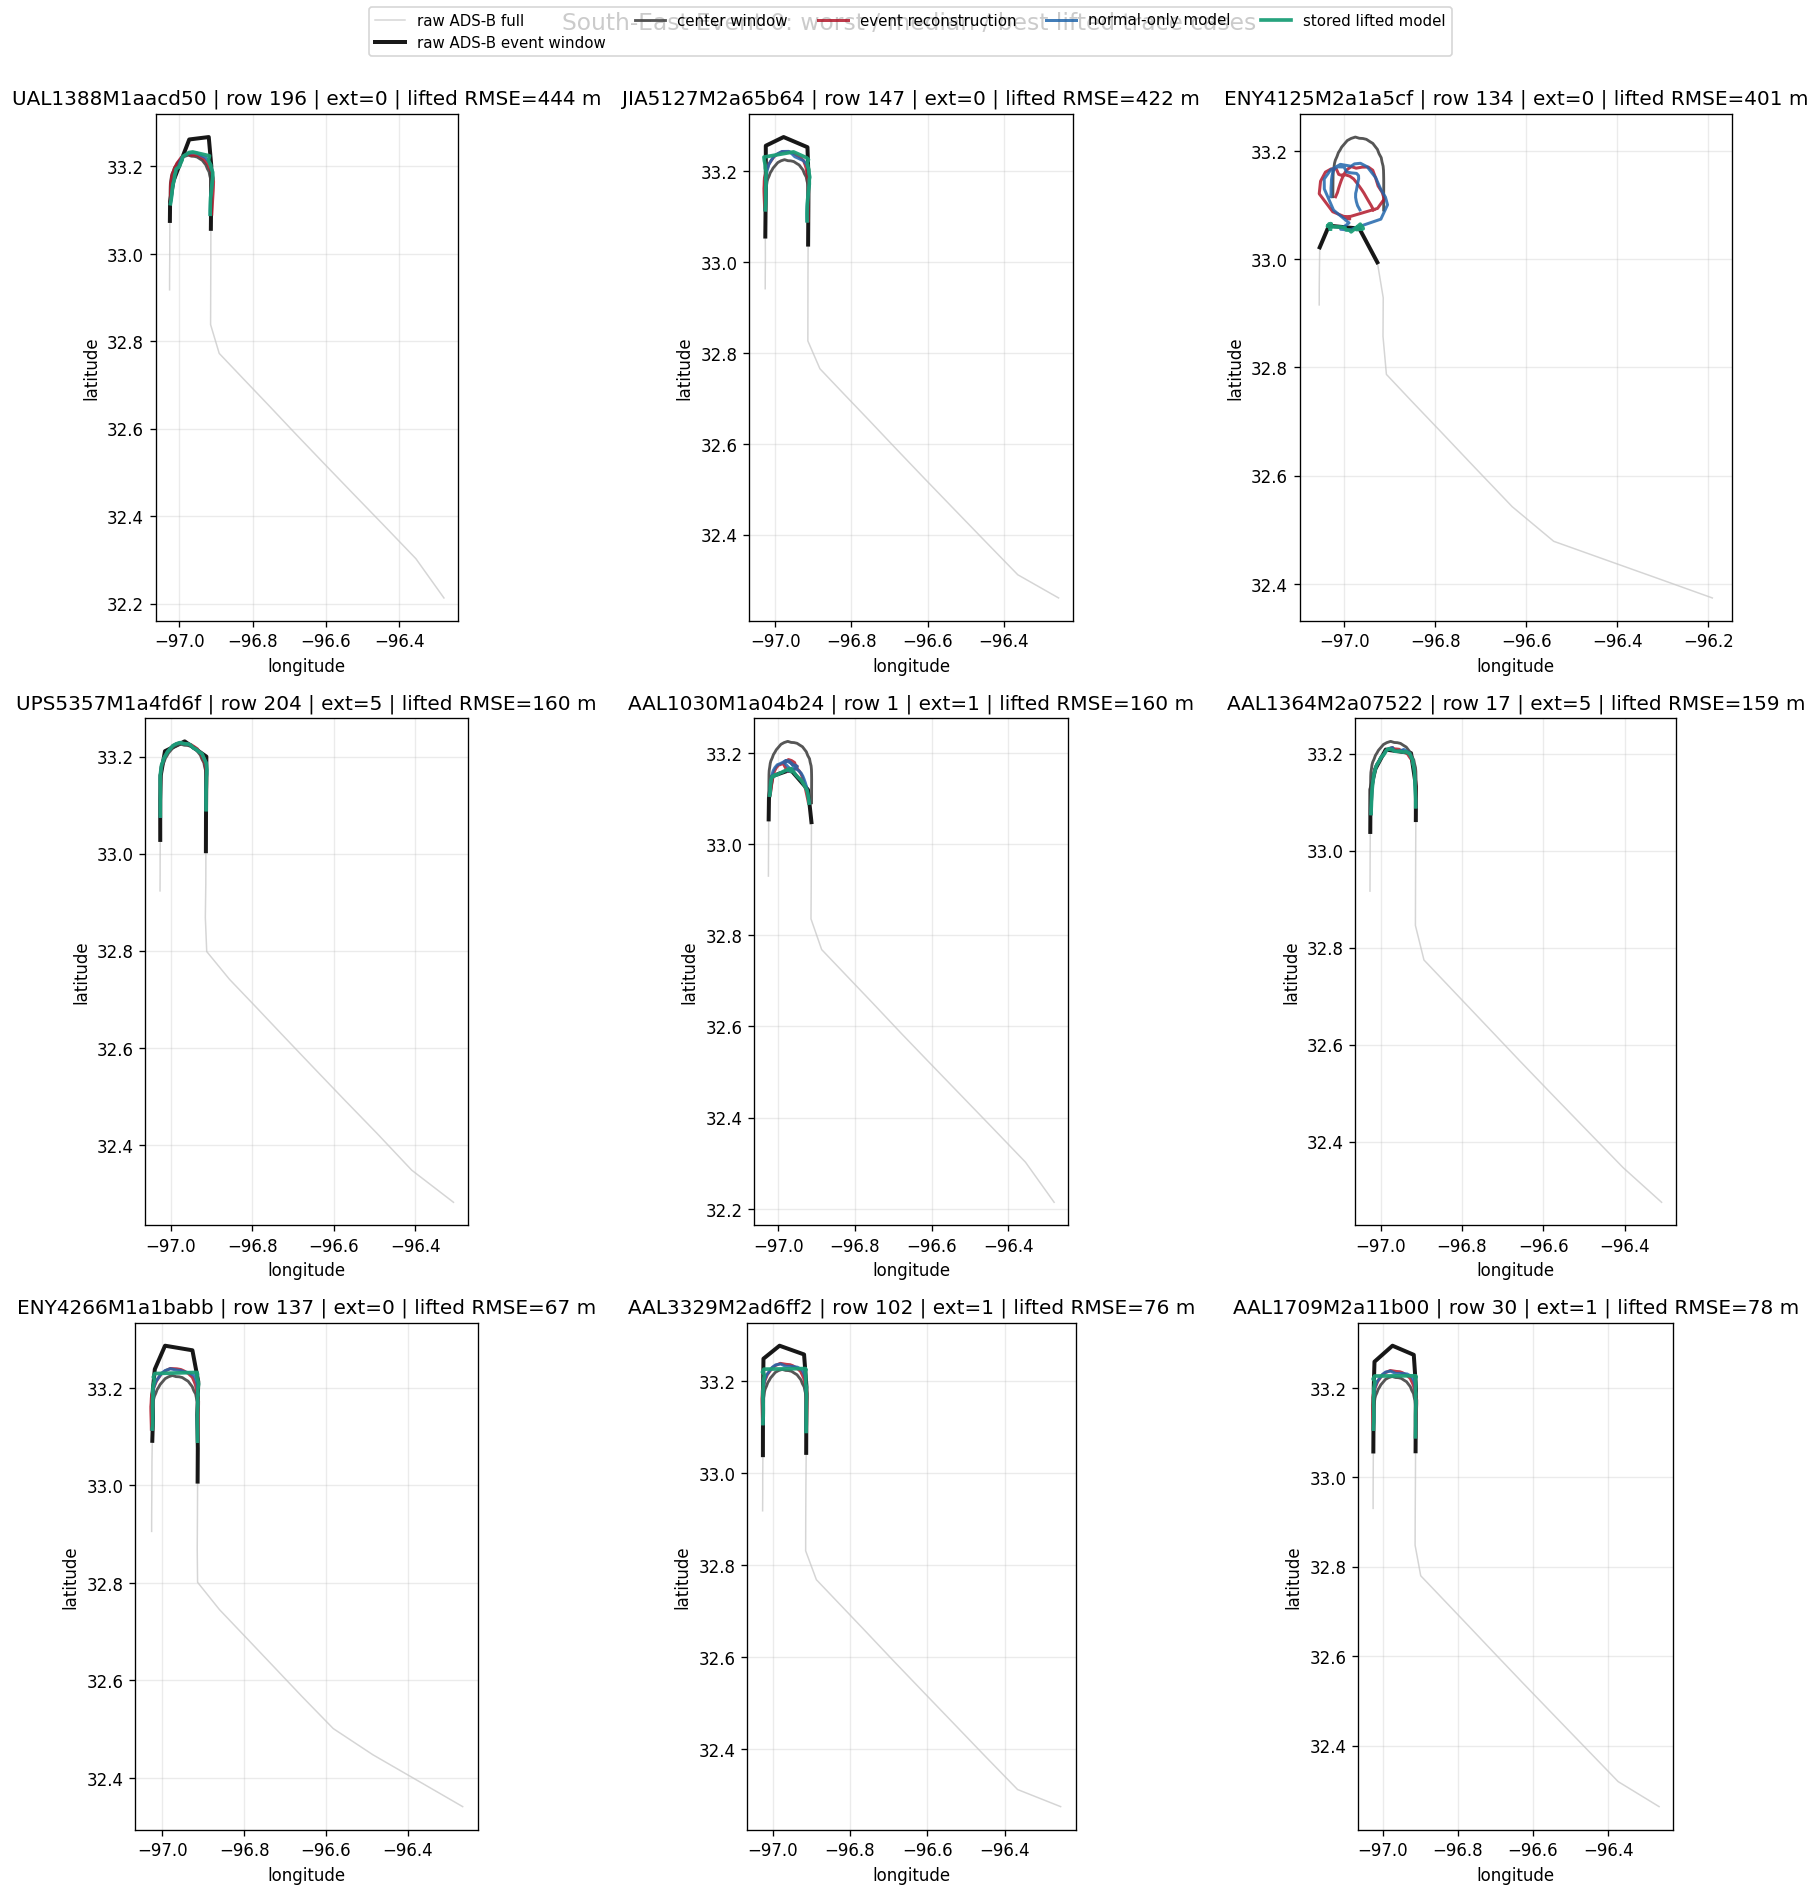

In [6]:
worst = rows.sort_values("lifted_model_trace_rmse_m", ascending=False).head(3)
median = rows.loc[rows["lifted_model_trace_rmse_m"].sub(rows["lifted_model_trace_rmse_m"].median()).abs().sort_values().head(3).index]
best = rows.sort_values("lifted_model_trace_rmse_m", ascending=True).head(3)
selection = pd.concat([worst, median, best], ignore_index=True)
plot_flight_grid(selection, "South-East Event 0: worst / median / best lifted trace cases", columns=3);

## Manually Inspect One Flight

Set `flight_to_inspect` to a flight ID from the table above, or set `row_to_inspect` directly.

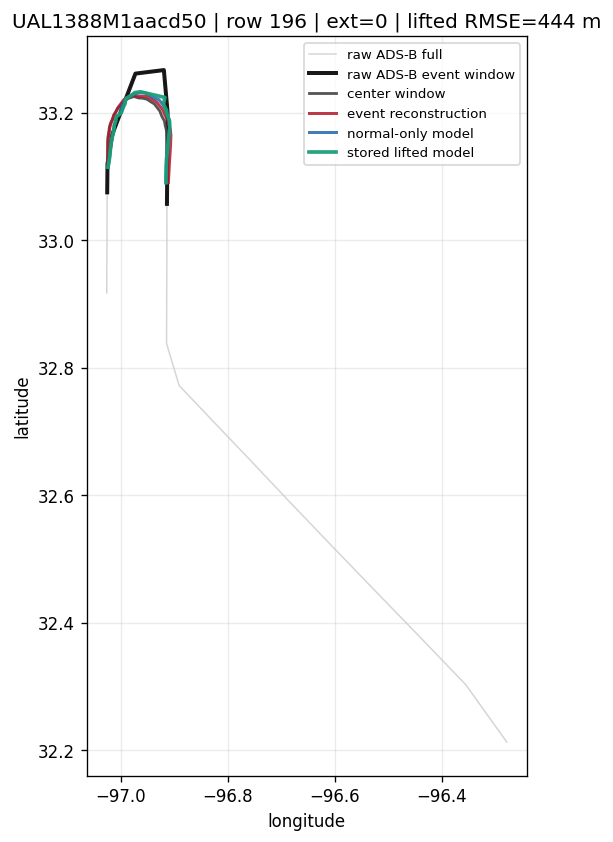

In [7]:
flight_to_inspect = rows.sort_values("lifted_model_trace_rmse_m", ascending=False).iloc[0].flight_id
row_to_inspect = None

fig, ax = plt.subplots(figsize=(8, 8))
plot_flight(flight_id=flight_to_inspect, row_index=row_to_inspect, ax=ax, full_context=True)
ax.legend(loc="best", fontsize=8);

## Export Inspection Figures

Optional: save the representative grid into `/tmp` for quick sharing.

PosixPath('/tmp/hllrd_se_event0_trace_inspection_grid.png')

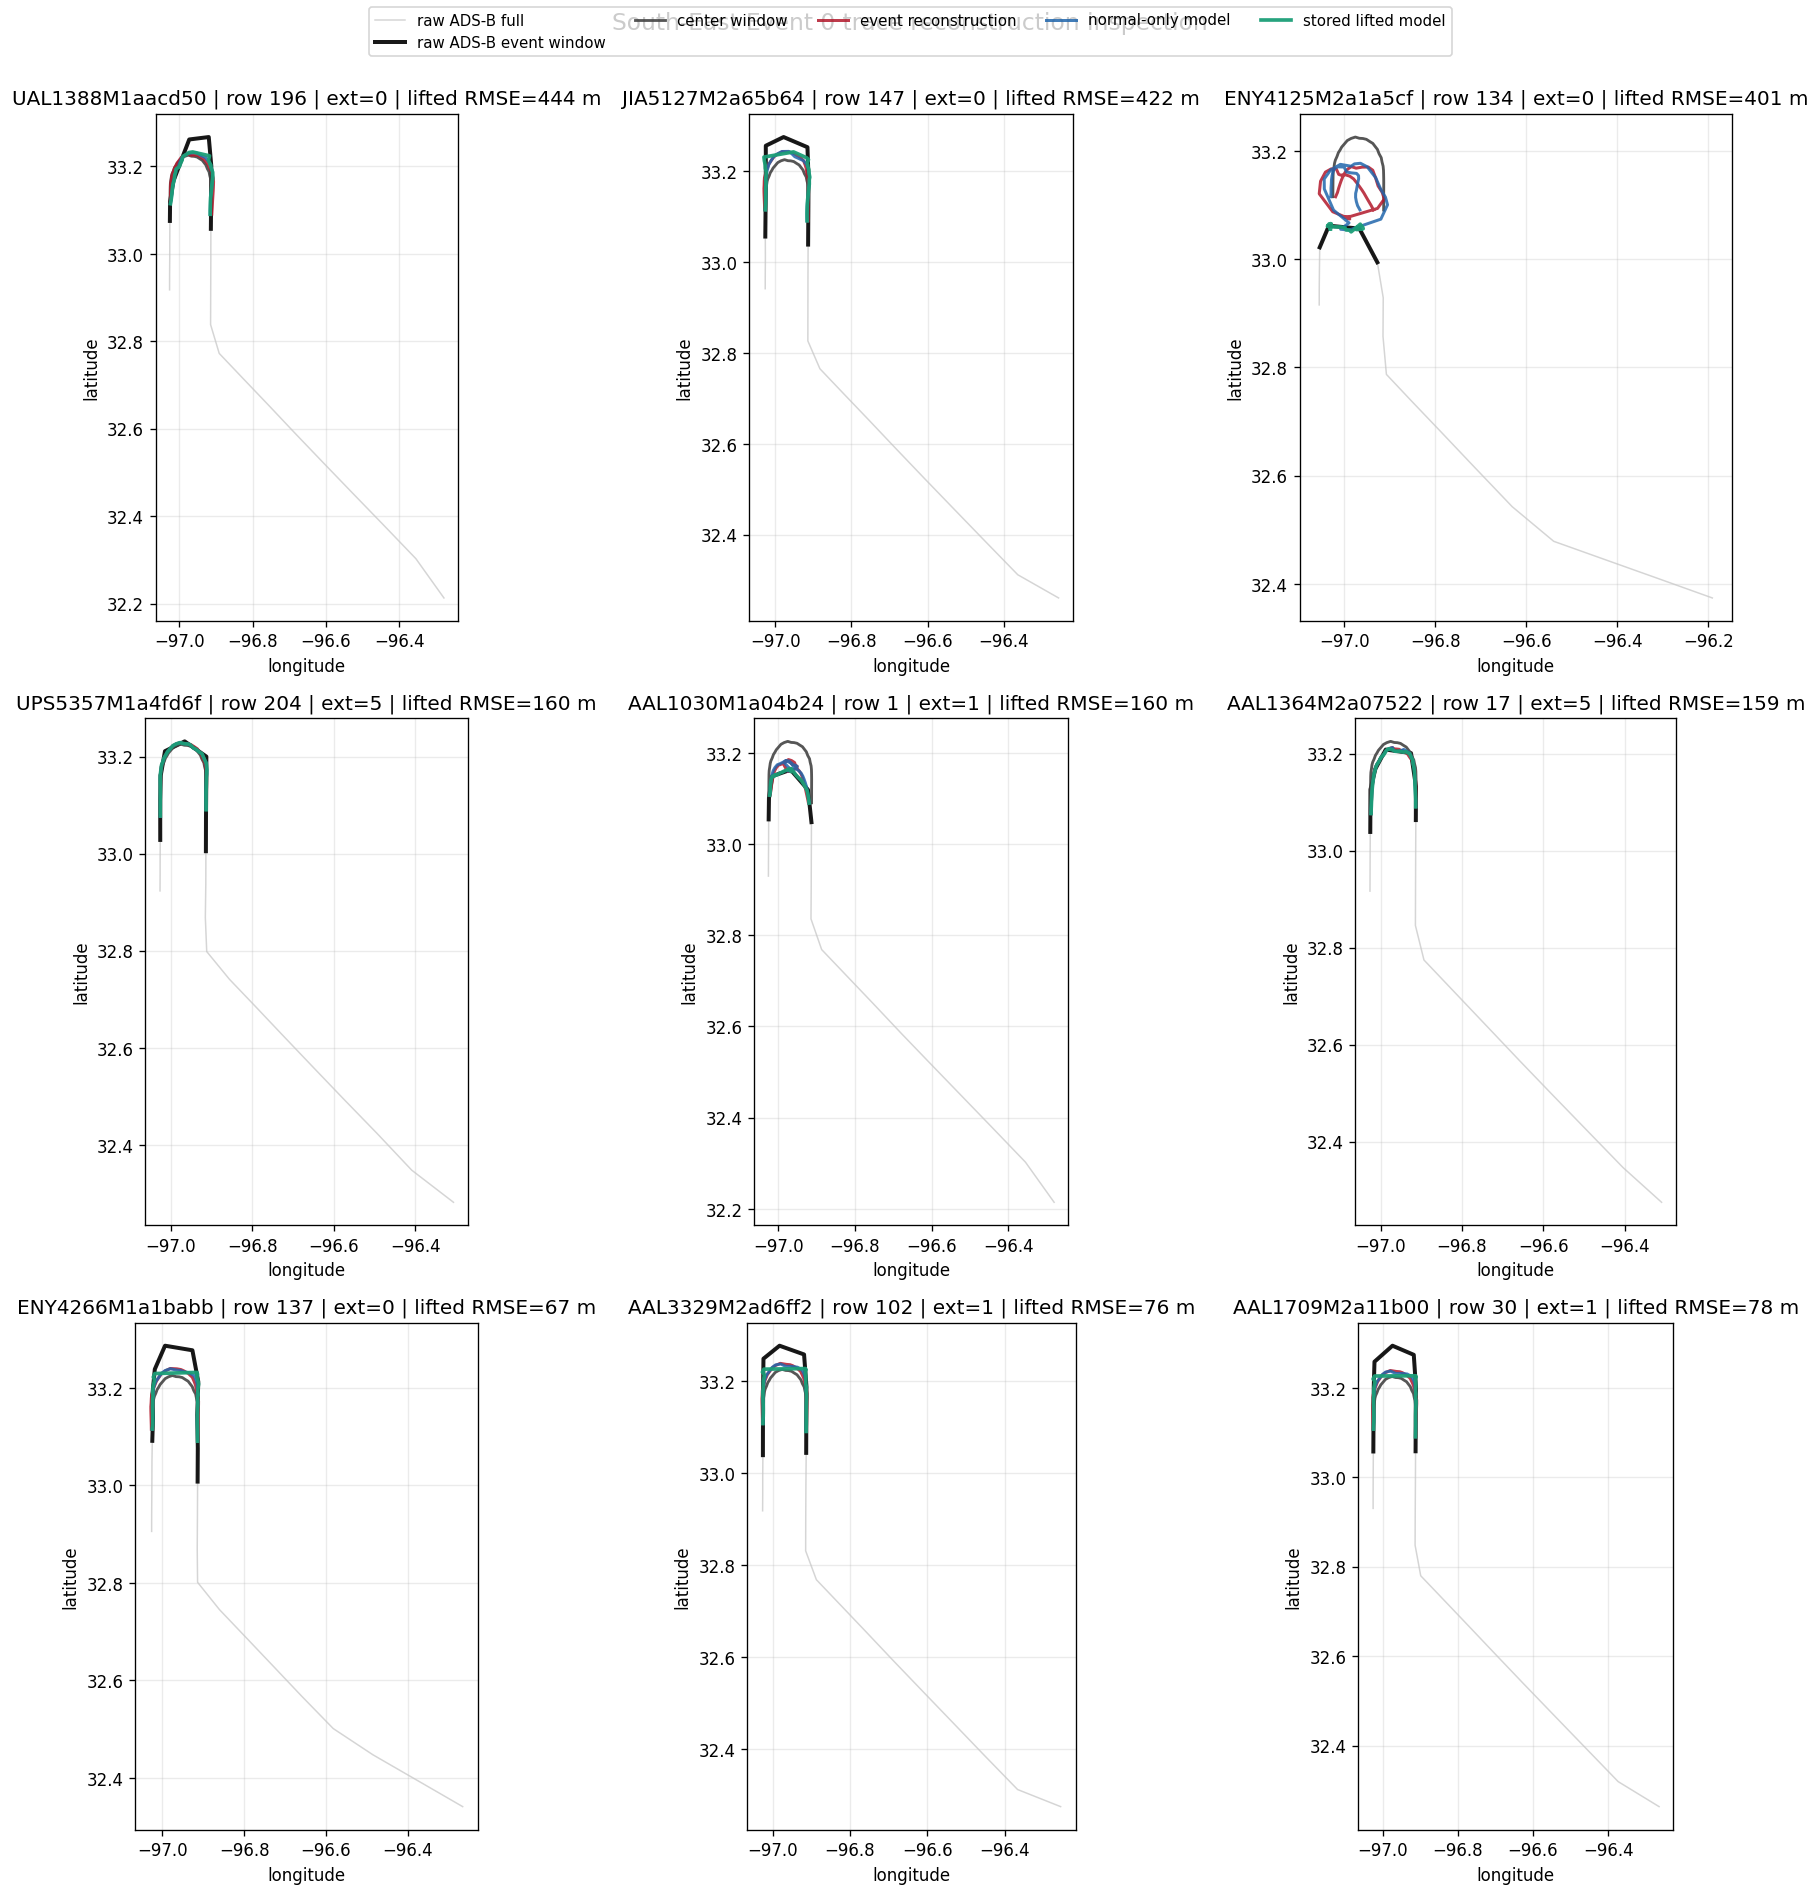

In [8]:
output_path = Path("/tmp/hllrd_se_event0_trace_inspection_grid.png")
fig = plot_flight_grid(selection, "South-East Event 0 trace reconstruction inspection", columns=3)
fig.savefig(output_path, dpi=180, bbox_inches="tight")
output_path